# Observations for STD_DATA_2025JUL_ANALYSIS.csv

This file is an output of Program 0 (Data and Measure Standardization) in the CMS Overall Star Rating SAS Pack.<br>
In this file, one row represents individual hospital. For each measure, we have a standardized score column (`std_[measure]`) and a denominator column (`[measure]_DEN`). This is the input file for Program 1.

Key: `provider_ID`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 1. Load data

In [2]:
df = pd.read_csv("STD_DATA_2025JUL_ANALYSIS.csv")
df.shape

(4566, 94)

In [3]:
df.head()

,PROVIDER_ID,IMM_3_DEN,EDAC_30_AMI_DEN,READM_30_HOSP_WIDE_DEN,EDAC_30_HF_DEN,OP_18B_DEN,OP_23_DEN,MORT_30_COPD_DEN,HAI_3_DEN_VOL,HAI_5_DEN_PRED,OP_13_DEN,HAI_5_DEN_VOL,HAI_1_DEN_VOL,READM_30_HIP_KNEE_DEN,H_NUMB_COMP,HAI_6_DEN_VOL,MORT_30_HF_DEN,PC_01_DEN,SAFE_USE_OF_OPIOIDS_DEN,READM_30_COPD_DEN,OP_10_DEN,COMP_HIP_KNEE_DEN,HAI_2_DEN_PRED,OP_29_DEN,OP_22_DEN,MORT_30_AMI_DEN,MORT_30_PN_DEN,OP_36_DEN,MORT_30_CABG_DEN,HAI_1_DEN_PRED,HAI_6_DEN_PRED,H_RESP_RATE_P,HCP_COVID_19_DEN,READM_30_CABG_DEN,PSI_90_SAFETY_DEN,HAI_3_DEN_PRED,OP_8_DEN,MORT_30_STK_DEN,PSI_4_SURG_COMP_DEN,HAI_2_DEN_VOL,OP_32_DEN,OP_35_ED_DEN,OP_35_ADM_DEN,SEP_1_DEN,EDAC_30_PN_DEN,HAI_4_DEN_VOL,HAI_4_DEN_PRED,Total_m_cnt,std_MORT_30_AMI,std_MORT_30_CABG,std_MORT_30_COPD,std_MORT_30_HF,std_MORT_30_PN,std_MORT_30_STK,std_PSI_4_SURG_COMP,std_COMP_HIP_KNEE,std_HAI_1,std_HAI_2,std_HAI_3,std_HAI_4,std_HAI_5,std_HAI_6,std_PSI_90_SAFETY,std_EDAC_30_AMI,std_EDAC_30_HF,std_EDAC_30_PN,std_OP_32,std_READM_30_CABG,std_READM_30_COPD,std_READM_30_HIP_KNEE,std_READM_30_HOSP_WIDE,std_OP_35_ADM,std_OP_35_ED,std_OP_36,std_H_COMP_1_STAR_RATING,std_H_COMP_2_STAR_RATING,std_H_COMP_3_STAR_RATING,std_H_COMP_5_STAR_RATING,std_H_COMP_6_STAR_RATING,std_H_COMP_7_STAR_RATING,std_H_GLOB_STAR_RATING,std_H_INDI_STAR_RATING,std_HCP_COVID_19,std_IMM_3,std_OP_10,std_OP_13,std_OP_18B,std_OP_22,std_OP_23,std_OP_29,std_OP_8,std_PC_01,std_SAFE_USE_OF_OPIOIDS,std_SEP_1
0,010001,4115.0,296.0,2924.0,679.0,345.0,NaN,122.0,240.0,11.232,193.0,103195.0,9538.0,34.0,643.0,103195.0,610.0,46.0,4303.0,130.0,1478.0,32.0,23.712,17.0,52960.0,291.0,489.0,668.0,157.0,10.082,65.234,17.0,2712.0,151.0,NaN,6.618,66.0,414.0,125.0,16332.0,170.0,202.0,202.0,131.0,490.0,NaN,NaN,44,1.405923,-1.045370,1.011496,0.650904,-0.315375,0.023766,-0.732077,0.698729,0.303670,0.739078,-0.467783,NaN,0.476446,-0.105703,0.103001,1.024273,-0.368843,-0.448127,0.289973,0.607499,0.859382,0.192452,0.768359,-1.028886,0.627910,-0.257980,-1.154064,0.570761,-0.231671,-0.254181,-0.312251,0.933177,0.719371,0.020336,-0.525017,1.044716,0.080291,0.781373,-1.062058,-1.138829,NaN,-3.171398,0.588011,0.140984,0.563049,0.449772
1,010005,2407.0,NaN,1056.0,176.0,1154.0,13.0,133.0,102.0,1.631,177.0,35424.0,3410.0,144.0,714.0,33872.0,162.0,193.0,2244.0,143.0,850.0,138.0,3.262,180.0,56820.0,28.0,301.0,406.0,NaN,2.074,9.503,17.0,2431.0,NaN,NaN,2.867,109.0,97.0,43.0,7200.0,739.0,107.0,107.0,288.0,305.0,NaN,NaN,42,-1.492798,NaN,0.150309,-0.366857,-1.766289,-0.083025,-0.576021,1.158692,-0.332255,-1.072825,1.149255,NaN,-2.749027,-0.428086,-0.058780,NaN,-0.330781,0.548360,-1.035150,NaN,2.448388,1.038374,1.653526,1.891523,-0.071403,-2.992838,-0.243473,0.570761,-1.172260,0.768655,0.678414,-0.038195,-0.226012,0.529388,-0.396114,-0.264294,-1.615666,0.373993,0.303229,-0.270542,-0.094782,0.334795,-1.162943,0.346333,-0.171693,0.925313
2,010006,2560.0,315.0,2560.0,508.0,349.0,NaN,141.0,73.0,5.397,243.0,68020.0,4826.0,90.0,1620.0,64728.0,455.0,22.0,3521.0,154.0,973.0,84.0,11.164,82.0,42286.0,292.0,616.0,484.0,102.0,5.279,37.771,18.0,2095.0,91.0,NaN,1.935,NaN,271.0,102.0,8700.0,1355.0,NaN,NaN,162.0,621.0,116.0,1.086,42,-3.138018,-2.730472,-0.512142,-0.135547,-0.626285,-0.243212,-1.004318,-0.834482,0.977642,1.028777,1.149255,1.108414,0.595372,0.965067,-0.867684,-0.541852,0.368600,-0.017926,1.105434,-0.951609,0.859382,0.192452,-0.116807,NaN,NaN,-1.283552,-1.154064,-1.443055,-1.172260,-1.277016,-1.302916,-1.009567,-1.171395,-0.488716,-0.525017,-0.591547,-1.064480,0.315796,-0.313955,0.597745,NaN,-0.452310,NaN,0.551682,-0.171693,-0.263539
3,010007,345.0,NaN,234.0,35.0,594.0,NaN,42.0,NaN,NaN,NaN,NaN,NaN,33.0,175.0,5267.0,33.0,NaN,NaN,41.0,151.0,33.0,NaN,111.0,11202.0,NaN,101.0,59.0,NaN,NaN,1.994,24.0,245.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,109.0,NaN,NaN,21.0,85.0,NaN,NaN,28,NaN,NaN,-2.698232,-1.014523,-3.804479,NaN,NaN,0.085445,NaN,NaN,NaN,NaN,NaN,-1.284702,0.372636,NaN,-0.858886,-0.764193,-0.219690,NaN,-0.431686,0.192452,-0.706918,NaN,NaN,-0.599837,1.577707,1.577668,0.708919,1.791491,1.669078,

In [4]:
df.columns.tolist()

['PROVIDER_ID',
 'IMM_3_DEN',
 'EDAC_30_AMI_DEN',
 'READM_30_HOSP_WIDE_DEN',
 'EDAC_30_HF_DEN',
 'OP_18B_DEN',
 'OP_23_DEN',
 'MORT_30_COPD_DEN',
 'HAI_3_DEN_VOL',
 'HAI_5_DEN_PRED',
 'OP_13_DEN',
 'HAI_5_DEN_VOL',
 'HAI_1_DEN_VOL',
 'READM_30_HIP_KNEE_DEN',
 'H_NUMB_COMP',
 'HAI_6_DEN_VOL',
 'MORT_30_HF_DEN',
 'PC_01_DEN',
 'SAFE_USE_OF_OPIOIDS_DEN',
 'READM_30_COPD_DEN',
 'OP_10_DEN',
 'COMP_HIP_KNEE_DEN',
 'HAI_2_DEN_PRED',
 'OP_29_DEN',
 'OP_22_DEN',
 'MORT_30_AMI_DEN',
 'MORT_30_PN_DEN',
 'OP_36_DEN',
 'MORT_30_CABG_DEN',
 'HAI_1_DEN_PRED',
 'HAI_6_DEN_PRED',
 'H_RESP_RATE_P',
 'HCP_COVID_19_DEN',
 'READM_30_CABG_DEN',
 'PSI_90_SAFETY_DEN',
 'HAI_3_DEN_PRED',
 'OP_8_DEN',
 'MORT_30_STK_DEN',
 'PSI_4_SURG_COMP_DEN',
 'HAI_2_DEN_VOL',
 'OP_32_DEN',
 'OP_35_ED_DEN',
 'OP_35_ADM_DEN',
 'SEP_1_DEN',
 'EDAC_30_PN_DEN',
 'HAI_4_DEN_VOL',
 'HAI_4_DEN_PRED',
 'Total_m_cnt',
 'std_MORT_30_AMI',
 'std_MORT_30_CABG',
 'std_MORT_30_COPD',
 'std_MORT_30_HF',
 'std_MORT_30_PN',
 'std_MORT_30_STK

## 2. Column structure

We can now split columns into std score columns, denominator columns, and the ID column.

In [5]:
std_cols = [c for c in df.columns if c.lower().startswith('std_')]
den_cols = [c for c in df.columns if c.upper().endswith('_DEN')]
other_cols = [c for c in df.columns if c not in std_cols and c not in den_cols]

print("ID/other columns:", other_cols)
print("Number of std_ columns:", len(std_cols))
print("Number of _DEN columns:", len(den_cols))

ID/other columns: ['PROVIDER_ID', 'HAI_3_DEN_VOL', 'HAI_5_DEN_PRED', 'HAI_5_DEN_VOL', 'HAI_1_DEN_VOL', 'H_NUMB_COMP', 'HAI_6_DEN_VOL', 'HAI_2_DEN_PRED', 'HAI_1_DEN_PRED', 'HAI_6_DEN_PRED', 'H_RESP_RATE_P', 'HAI_3_DEN_PRED', 'HAI_2_DEN_VOL', 'HAI_4_DEN_VOL', 'HAI_4_DEN_PRED', 'Total_m_cnt']
Number of std_ columns: 46
Number of _DEN columns: 32


In [6]:
df.dtypes.value_counts()

float64    92
str         1
int64       1
Name: count, dtype: int64

## 3. Duplicates and ID check

In [8]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate provider_ID:", df['PROVIDER_ID'].duplicated().sum())
print("Unique providers:", df['PROVIDER_ID'].nunique())

Duplicate rows: 0
Duplicate provider_ID: 0
Unique providers: 4566


## 4. Missing values by measure

Missing values are expected here: not every hospital reports every measure. Percent missing per std column shows reporting coverage.

In [9]:
missing_pct = (df[std_cols].isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct

std_HAI_4                   85.830048
std_OP_8                    84.012265
std_READM_30_CABG           80.573806
std_MORT_30_CABG            80.530004
std_OP_35_ADM               67.038984
std_OP_35_ED                67.038984
std_OP_23                   65.878230
std_PSI_4_SURG_COMP         65.637319
std_EDAC_30_AMI             65.286903
std_HAI_5                   62.571178
std_COMP_HIP_KNEE           62.155059
std_HAI_3                   60.840999
std_READM_30_HIP_KNEE       60.665791
std_OP_13                   58.388086
std_HAI_1                   56.657906
std_MORT_30_AMI             56.154183
std_MORT_30_STK             51.533071
std_HAI_2                   50.678931
std_PC_01                   50.459921
std_MORT_30_COPD            42.028033
std_READM_30_COPD           41.130092
std_OP_36                   38.677179
std_OP_29                   37.056505
std_HAI_6                   35.326325
std_PSI_90_SAFETY           35.260622
std_OP_32                   31.296540
std_MORT_30_

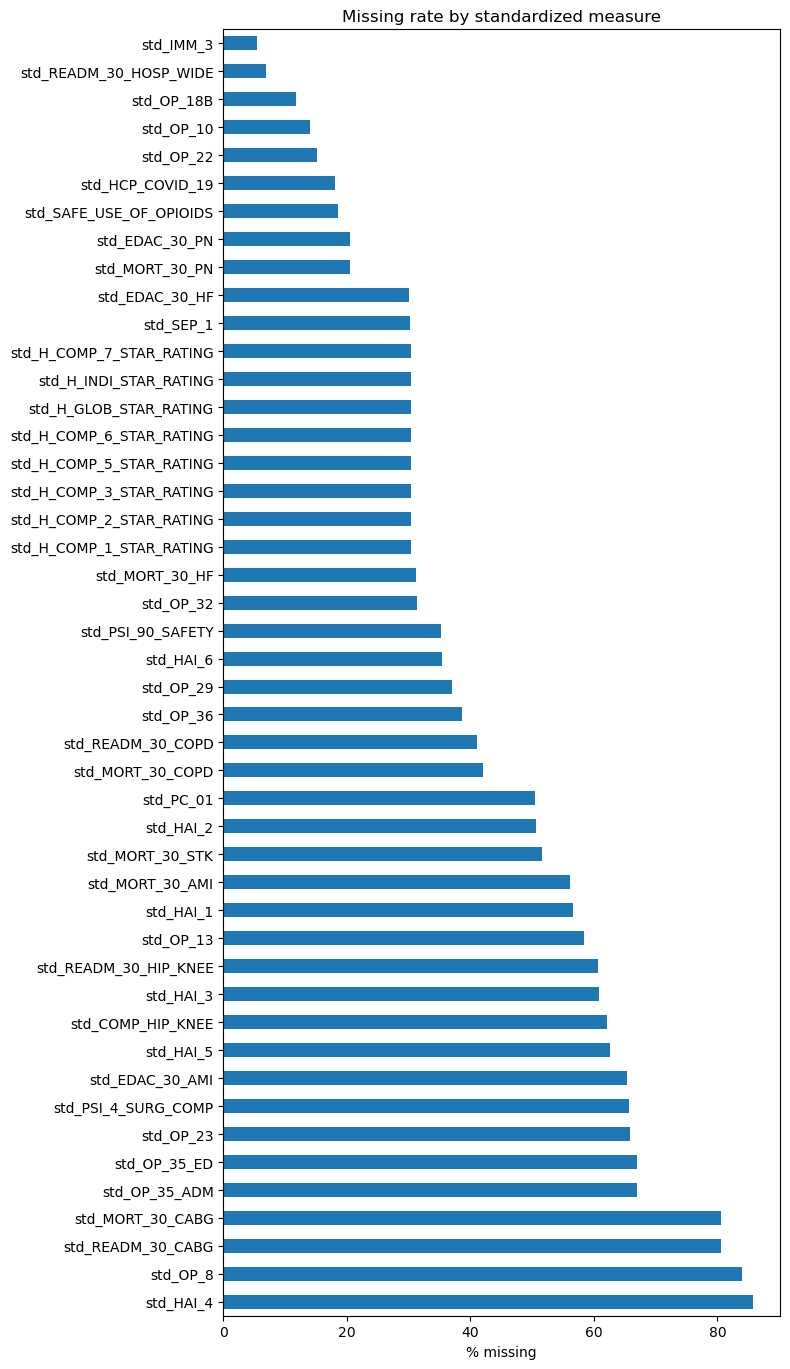

In [10]:
missing_pct.plot(kind='barh', figsize=(8, max(6, len(std_cols)*0.3)))
plt.xlabel('% missing')
plt.title('Missing rate by standardized measure')
plt.tight_layout()
plt.show()

As per doc, measures with <= 100 hospitals reporting are excluded upstream (see `less100_measure` output), so all std columns here should have reasonable coverage.

In [11]:
reporting_counts = df[std_cols].notna().sum().sort_values()
print("Min hospitals reporting a measure:", reporting_counts.min())
reporting_counts.head(10)

Min hospitals reporting a measure: 647


std_HAI_4               647
std_OP_8                730
std_READM_30_CABG       887
std_MORT_30_CABG        889
std_OP_35_ED           1505
std_OP_35_ADM          1505
std_OP_23              1558
std_PSI_4_SURG_COMP    1569
std_EDAC_30_AMI        1585
std_HAI_5              1709
dtype: int64

## 5. Rows with no measures reported

Program 0 should exclude hospitals reporting none of the included measures, so no row should be all-missing across std columns.

In [12]:
all_missing = df[std_cols].isna().all(axis=1)
print("Hospitals with zero measures reported:", all_missing.sum())

Hospitals with zero measures reported: 0


## 6. Distribution of standardized scores

Each std_ column is standardized to mean 0, std 1. We can check a sample of columns.

In [13]:
df[std_cols].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
std_MORT_30_AMI,-3.396582e-12,1.0,-3.921456,3.834581
std_MORT_30_CABG,-1.271091e-11,1.0,-5.017396,2.084105
std_MORT_30_COPD,5.213444e-12,1.0,-5.811754,2.667625
std_MORT_30_HF,-1.333121e-11,1.0,-5.224352,3.195307
std_MORT_30_PN,6.696059e-12,1.0,-4.633573,3.242820
std_MORT_30_STK,-1.943069e-12,1.0,-4.141088,3.067313
std_PSI_4_SURG_COMP,-5.098654e-13,1.0,-3.454486,3.989052
std_COMP_HIP_KNEE,3.530083e-12,1.0,-5.127474,2.998546
std_HAI_1,3.233957e-12,1.0,-13.432591,0.977642
std_HAI_2,-1.114564e-11,1.0,-7.206212,1.028777


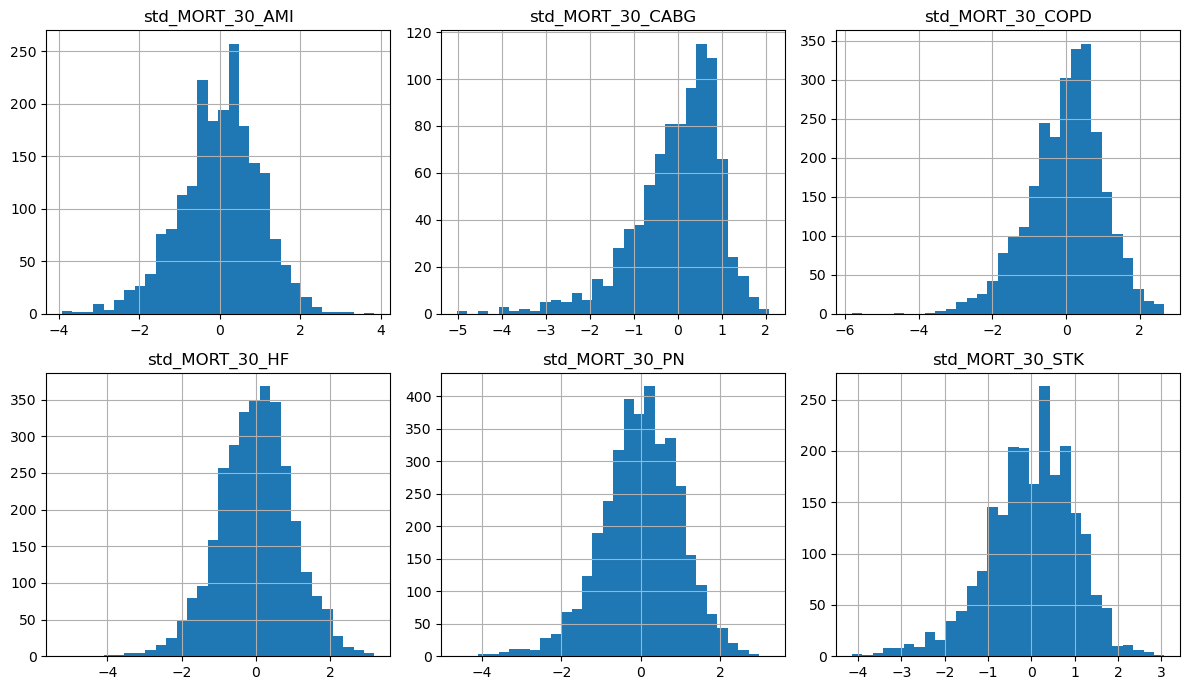

In [14]:
sample_cols = std_cols[:6]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.flat, sample_cols):
    df[col].hist(ax=ax, bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 7. Denominator columns

`_DEN` gives the number of cases underlying each measure score. Should be missing exactly where the paired std_ column is missing.

In [15]:
df[den_cols].describe().T[['mean', 'min', 'max']]

,mean,min,max
IMM_3_DEN,2123.825614,0.0,54229.0
EDAC_30_AMI_DEN,198.102208,50.0,1134.0
READM_30_HOSP_WIDE_DEN,1198.559765,25.0,21662.0
EDAC_30_HF_DEN,301.609145,25.0,3490.0
OP_18B_DEN,592.006943,12.0,95845.0
OP_23_DEN,19.865854,11.0,86.0
MORT_30_COPD_DEN,97.928598,25.0,635.0
OP_13_DEN,259.720000,45.0,3280.0
READM_30_HIP_KNEE_DEN,158.291203,25.0,4501.0
MORT_30_HF_DEN,266.277442,25.0,2875.0


In [16]:
# Check std_X and X_DEN missingness align
mismatches = {}
for std_col in std_cols:
    measure = std_col[4:]  # strip 'std_'
    den_col = measure + '_DEN'
    if den_col in df.columns:
        n_mismatch = (df[std_col].isna() != df[den_col].isna()).sum()
        if n_mismatch > 0:
            mismatches[std_col] = n_mismatch

print("Columns with std/DEN missingness mismatch:", mismatches if mismatches else "none")

Columns with std/DEN missingness mismatch: {'std_PSI_90_SAFETY': np.int64(2956), 'std_HCP_COVID_19': np.int64(7), 'std_IMM_3': np.int64(2), 'std_SAFE_USE_OF_OPIOIDS': np.int64(6)}
